# Vanilla CLIP Zero-Shot Baseline
Compositional image retrieval on CelebA (test split) with frozen CLIP ViT-B/32 and naive latent arithmetic: `q = normalize(v_ref + Σt⁺ − Σt⁻)`.

This is the lower-bound baseline required by the assignment roadmap (§3.2); the fusion module developed later is compared against these numbers.

In [1]:
# Setup — works both locally (repo root) and on Colab.
import importlib.util, sys
try:
    ON_COLAB = importlib.util.find_spec('google.colab') is not None
except ModuleNotFoundError:
    ON_COLAB = False
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !mkdir -p /content/datasets
    !unzip -q -n /content/drive/MyDrive/datasets/celeba.zip -d /content/datasets/
    # src/ modules must sit next to this notebook on Drive
    sys.path.insert(0, '/content/drive/MyDrive/Clipper')


In [2]:
from src.data import get_paths, load_annotations, load_dataset
from src.evaluation import run_benchmark
from src.features import ClipEncoder, load_or_extract
from src.retrieval import PROMPTS, compose, parse_query, rank

paths = get_paths()
celeba = load_dataset(paths)
annotations = load_annotations(paths)
print(f'{len(celeba)} test images, {len(annotations)} benchmark queries')

19962 test images, 14 benchmark queries


## Offline feature extraction
Following CLAY, the visual database is embedded once with the frozen encoder and cached; retrieval never re-encodes images.

In [3]:
encoder = ClipEncoder()
features = load_or_extract(encoder, celeba, paths.features_dir)
features.shape

torch.Size([19962, 512])

## Benchmark
Recall@K and Precision@K at K ∈ {1, 5, 10}, averaged over the source images of each query. Prompts use CLIP-paper-style templates (e.g. `Heavy_Makeup` → *a photo of a person with heavy makeup*).

In [4]:
results = run_benchmark(annotations, features, encoder.encode_texts)
results.style.format({c: '{:.3f}' for c in results.columns[2:]})

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

,query,sources,R@1,R@5,R@10,P@1,P@5,P@10
0,+Smiling,4786,0.065,0.184,0.259,0.065,0.048,0.040
1,+Eyeglasses,2196,0.020,0.084,0.134,0.020,0.020,0.018
2,-Heavy_Makeup,4087,0.029,0.094,0.149,0.029,0.022,0.019
3,+Male,1595,0.009,0.024,0.043,0.009,0.006,0.006
4,-Young,5355,0.010,0.032,0.056,0.010,0.008,0.007
5,+Blond_Hair,5469,0.024,0.082,0.132,0.024,0.022,0.020
6,+Mustache,301,0.066,0.166,0.236,0.066,0.047,0.037
7,-Young,5355,0.010,0.032,0.056,0.010,0.008,0.007
8,"+Eyeglasses, +Smiling",612,0.025,0.062,0.095,0.025,0.014,0.011
9,"+Black_Hair, -Wavy_Hair",2572,0.026,0.098,0.149,0.026,0.023,0.020


## Qualitative examples

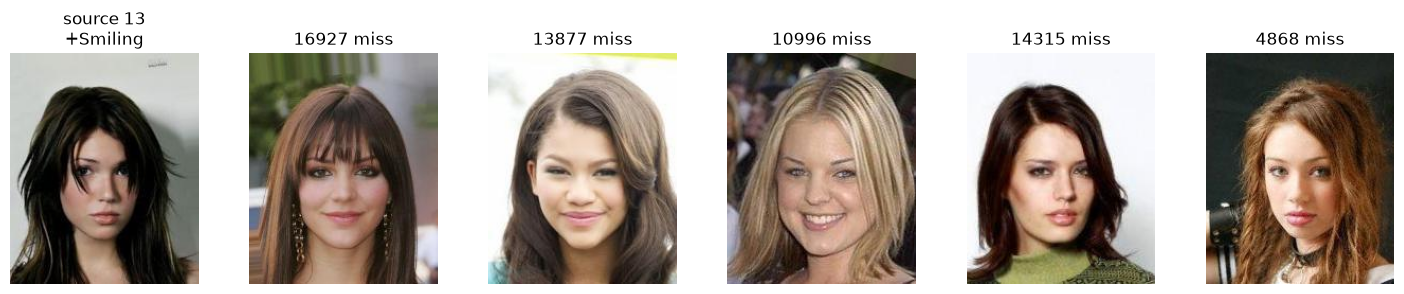

In [5]:
import torch
import matplotlib.pyplot as plt

def show_retrieval(query_idx: int, source_key: str, top_k: int = 5):
    entry = annotations[query_idx]
    pos, neg = parse_query(entry['query'])
    pos_t = encoder.encode_texts([PROMPTS[a] for a in pos]) if pos else torch.zeros((0, 512))
    neg_t = encoder.encode_texts([PROMPTS[a] for a in neg]) if neg else torch.zeros((0, 512))
    src = int(source_key)
    q = compose(features[src], pos_t, neg_t).unsqueeze(0)
    order = rank(q, features, exclude=[src])[0][:top_k].tolist()
    gt = set(entry['ground_truth'][source_key])
    fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3))
    axes[0].imshow(celeba[src][0]); axes[0].set_title(f'source {src}\n{entry["query"]}')
    for ax, idx in zip(axes[1:], order):
        ax.imshow(celeba[idx][0])
        ax.set_title(f'{idx} {"HIT" if idx in gt else "miss"}')
    for ax in axes: ax.axis('off')
    plt.show()

# Success and failure examples — pick after inspecting results
first_key = next(iter(annotations[0]['ground_truth']))
show_retrieval(0, first_key)